# Regular TensorFlow vs TinyML Audio Classification

This notebook is both an experiment and a written explanation for the Wahlfachprojekt comparison. It compares a regular TensorFlow/Keras audio classifier with a quantized TensorFlow Lite model for a small sound-classification task.

The important idea is that the **regular model is the laptop/Colab baseline**. It does not need to fit on the ESP32. The **TinyML/TFLite model is the edge-device candidate**. That is the model style that could later run on the ESP32 + INMP441 audio node.

The comparison does **not** require the physical microphone yet. It uses a reproducible audio dataset on the laptop or in Colab. Later, the same output idea can be connected to openHAB through MQTT with `label`, `confidence`, `rms`, and `inference_ms` instead of raw audio.

Recommended kernels:

- Local VS Code kernel: `Safety TinyML (.venv)` for editing and light runs.
- Colab runtime/kernel: heavier TensorFlow training if the local machine is slow.

Important Colab note: when this runs with a Colab kernel, files are downloaded into the **remote Colab filesystem**, not into your local Windows project folder. If you want the generated models locally, download them from Colab after the run.

## Comparison Idea

The project question is not just "can we train an audio model?". The useful question is: **what changes when the same audio-classification task is moved from a normal laptop TensorFlow workflow into a TinyML-style deployment?**

- **Regular model:** trained and evaluated as a normal Keras model on the laptop or in Colab. This is the reference point.
- **Tiny model:** converted from the same model to TensorFlow Lite with int8 quantization. This is smaller and closer to what a microcontroller can use.
- **Input:** short audio windows transformed into spectrograms. A spectrogram is an image-like representation of sound energy over time and frequency.
- **Output:** semantic sound-context labels that can later influence the openHAB risk score.

ESC-50 contains 50 sound classes. These can be grouped into 5 semantic super-categories:

```text
animals
natural_soundscape_water
human_non_speech
interior_domestic
exterior_urban
```

This notebook uses those 5 super-categories by default. That is a better first comparison than only using a few hand-picked classes, because it uses the dataset's broader semantic structure.

For the safety-monitoring story, the interpretation is still useful: for example, `interior_domestic` and `exterior_urban` sounds can be treated differently from `animals` or `natural_soundscape_water`. A smaller safety-specific subset can still be used later if we want labels such as `siren_alarm` or `impact_or_glass`.

In [47]:
# Run this first. A Colab kernel is remote and does not use the local .venv.
# Therefore Colab installs packages here, while the local VS Code kernel uses requirements.txt.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Colab runtime detected. Installing notebook dependencies in the remote Colab environment...')
    get_ipython().run_line_magic('pip', 'install -q tensorflow numpy matplotlib scikit-learn')
else:
    print('Local kernel detected. Use the local .venv and install dependencies with:')
    print('python -m pip install -r requirements.txt')

Colab runtime detected. Installing notebook dependencies in the remote Colab environment...


In [48]:
from pathlib import Path
import os
import time
import tempfile

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print('TensorFlow:', tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

cwd = Path.cwd()
if cwd.name == 'notebooks' and cwd.parent.name == 'tinyml':
    TINYML_ROOT = cwd.parent
elif (cwd / 'tinyml').exists():
    TINYML_ROOT = cwd / 'tinyml'
else:
    TINYML_ROOT = cwd

print('TinyML root:', TINYML_ROOT)

TensorFlow: 2.20.0
TinyML root: /content


## Dataset

The default dataset is **ESC-50**, a public environmental sound dataset. It contains 50 semantic sound classes organized into 5 broader categories.

This notebook uses the 5 broader categories by default because that gives a compact but meaningful classification task:

```text
animals
natural_soundscape_water
human_non_speech
interior_domestic
exterior_urban
```

There is also an optional `esc50_safety_subset` task if we later want a smaller set of labels that sounds more directly like the safety-monitoring use case. The smaller Speech Commands fallback is kept only for troubleshooting if the ESC-50 download is too slow.

### Why you may not see files locally

If you run this notebook with a Colab kernel in VS Code, the code is executing on Google's remote Colab machine. Therefore downloaded audio files will appear under a Colab path like `/content/data/raw`, not under `C:\\Users\\...` on your laptop. This is normal. Generated model files also live remotely until you download them.

In [49]:
# Dataset mode:
# - 'esc50' uses the ESC-50 environmental sound dataset.
# - 'speech_commands' is a smaller fallback if the ESC-50 download is too slow.
DATASET_MODE = 'esc50'

# Task mode for ESC-50:
# - 'supercategories' uses all 50 ESC-50 classes grouped into 5 semantic categories.
# - 'safety_subset' uses a smaller hand-picked set of safety-relevant classes.
ESC50_TASK = 'supercategories'

DATA_ROOT = (TINYML_ROOT / 'data' / 'raw').resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)

if DATASET_MODE == 'esc50':
    import zipfile

    DATA_URL = 'https://github.com/karolpiczak/ESC-50/archive/master.zip'
    zip_path = tf.keras.utils.get_file(
        origin=DATA_URL,
        fname='ESC-50-master.zip',
        cache_dir=str(DATA_ROOT),
        cache_subdir='.',
        extract=True,
    )

    # Depending on TensorFlow/Keras and the runtime, extract=True may place the
    # archive contents in slightly different locations. Instead of assuming one
    # exact folder name, locate ESC-50 by searching for its metadata file.
    metadata_matches = list(DATA_ROOT.rglob('esc50.csv'))

    if not metadata_matches:
        print('ESC-50 metadata not found after automatic extraction; extracting zip manually...')
        with zipfile.ZipFile(zip_path, 'r') as archive:
            archive.extractall(DATA_ROOT)
        metadata_matches = list(DATA_ROOT.rglob('esc50.csv'))

    if not metadata_matches:
        print('Downloaded zip path:', zip_path)
        print('DATA_ROOT entries:', sorted([p.name for p in DATA_ROOT.iterdir()])[:20])
        raise RuntimeError('Could not find ESC-50 metadata file esc50.csv after download/extraction.')

    metadata_path = metadata_matches[0]
    dataset_dir = metadata_path.parent.parent

elif DATASET_MODE == 'speech_commands':
    DATA_URL = 'http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip'
    zip_path = tf.keras.utils.get_file(
        origin=DATA_URL,
        fname='mini_speech_commands.zip',
        cache_dir=str(DATA_ROOT),
        cache_subdir='.',
        extract=True,
    )
    dataset_dir = Path(zip_path).with_suffix('')
else:
    raise ValueError(f'Unknown DATASET_MODE: {DATASET_MODE}')

print('Dataset mode:', DATASET_MODE)
if DATASET_MODE == 'esc50':
    print('ESC-50 task:', ESC50_TASK)
print('Downloaded archive:', zip_path)
print('Dataset directory:', dataset_dir)
print('Directory exists:', dataset_dir.exists())
if dataset_dir.exists():
    print('Top-level entries:', sorted([p.name for p in dataset_dir.iterdir()])[:10])

Dataset mode: esc50
ESC-50 task: supercategories
Downloaded archive: /content/data/raw/./ESC-50-master_extracted
Dataset directory: /content/data/raw/ESC-50-master_extracted/ESC-50-master
Directory exists: True
Top-level entries: ['.circleci', '.github', '.gitignore', 'LICENSE', 'README.md', 'audio', 'esc50.gif', 'meta', 'pytest.ini', 'requirements.txt']


In [50]:
import csv

MAX_PER_CLASS = 800 if DATASET_MODE == 'esc50' and ESC50_TASK == 'supercategories' else 240

if DATASET_MODE == 'esc50':
    # ESC-50 has 5 official folds. We use folds 1-3 for training, fold 4 for validation, fold 5 for testing.
    # This is better than a random split because it keeps the dataset's intended evaluation structure.
    ESC50_SUPERCATEGORIES = {
        'animals': [
            'dog', 'rooster', 'pig', 'cow', 'frog', 'cat', 'hen', 'insects', 'sheep', 'crow'
        ],
        'natural_soundscape_water': [
            'rain', 'sea_waves', 'crackling_fire', 'crickets', 'chirping_birds',
            'water_drops', 'wind', 'pouring_water', 'toilet_flush', 'thunderstorm'
        ],
        'human_non_speech': [
            'crying_baby', 'sneezing', 'clapping', 'breathing', 'coughing',
            'footsteps', 'laughing', 'brushing_teeth', 'snoring', 'drinking_sipping'
        ],
        'interior_domestic': [
            'door_wood_knock', 'mouse_click', 'keyboard_typing', 'door_wood_creaks',
            'can_opening', 'washing_machine', 'vacuum_cleaner', 'clock_alarm',
            'clock_tick', 'glass_breaking'
        ],
        'exterior_urban': [
            'helicopter', 'chainsaw', 'siren', 'car_horn', 'engine', 'train',
            'church_bells', 'airplane', 'fireworks', 'hand_saw'
        ],
    }

    ESC50_SAFETY_SUBSET = {
        'siren_alarm': ['siren', 'clock_alarm'],
        'impact_or_glass': ['glass_breaking', 'door_wood_knock', 'fireworks'],
        'human_activity': ['clapping', 'footsteps', 'coughing'],
        'background': ['rain', 'wind', 'clock_tick'],
    }

    if ESC50_TASK == 'supercategories':
        LABEL_GROUPS = ESC50_SUPERCATEGORIES
    elif ESC50_TASK == 'safety_subset':
        LABEL_GROUPS = ESC50_SAFETY_SUBSET
    else:
        raise ValueError(f'Unknown ESC50_TASK: {ESC50_TASK}')

    LABELS = list(LABEL_GROUPS.keys())
    label_to_index = {name: i for i, name in enumerate(LABELS)}
    category_to_label = {category: label for label, categories in LABEL_GROUPS.items() for category in categories}

    paths = []
    labels = []
    folds = []
    original_categories = []
    metadata_path = dataset_dir / 'meta' / 'esc50.csv'
    audio_dir = dataset_dir / 'audio'

    with metadata_path.open(newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            category = row['category']
            if category not in category_to_label:
                continue
            grouped_label = category_to_label[category]
            paths.append(str(audio_dir / row['filename']))
            labels.append(label_to_index[grouped_label])
            folds.append(int(row['fold']))
            original_categories.append(category)

    paths = np.array(paths)
    labels = np.array(labels, dtype=np.int64)
    folds = np.array(folds, dtype=np.int64)
    original_categories = np.array(original_categories)

elif DATASET_MODE == 'speech_commands':
    TARGET_WORDS = ['yes', 'no']
    ALL_WORD_DIRS = sorted([p for p in dataset_dir.iterdir() if p.is_dir()])
    UNKNOWN_WORDS = [p.name for p in ALL_WORD_DIRS if p.name not in TARGET_WORDS]
    LABELS = ['yes', 'no', 'unknown', 'silence']
    label_to_index = {name: i for i, name in enumerate(LABELS)}

    collected_paths = []
    collected_labels = []

    for word in TARGET_WORDS:
        files = sorted((dataset_dir / word).glob('*.wav'))[:MAX_PER_CLASS]
        collected_paths.extend(files)
        collected_labels.extend([label_to_index[word]] * len(files))

    unknown_files = []
    per_unknown_word = max(1, MAX_PER_CLASS // len(UNKNOWN_WORDS))
    for word in UNKNOWN_WORDS:
        unknown_files.extend(sorted((dataset_dir / word).glob('*.wav'))[:per_unknown_word])
    unknown_files = unknown_files[:MAX_PER_CLASS]
    collected_paths.extend(unknown_files)
    collected_labels.extend([label_to_index['unknown']] * len(unknown_files))

    paths = np.array([str(p) for p in collected_paths])
    labels = np.array(collected_labels, dtype=np.int64)
    folds = None

print('Labels:', LABELS)
print('Audio files:', len(paths))
for label_name in LABELS:
    print(f'{label_name:28s}', int(np.sum(labels == label_to_index[label_name])))

if DATASET_MODE == 'esc50':
    print('Original ESC-50 classes used:', len(set(original_categories)))
    print('Example original classes:', sorted(set(original_categories))[:12])

if len(paths) == 0:
    raise RuntimeError('No audio files were collected. Check the dataset download/extraction path above.')

Labels: ['animals', 'natural_soundscape_water', 'human_non_speech', 'interior_domestic', 'exterior_urban']
Audio files: 2000
animals                      400
natural_soundscape_water     400
human_non_speech             400
interior_domestic            400
exterior_urban               400
Original ESC-50 classes used: 50
Example original classes: [np.str_('airplane'), np.str_('breathing'), np.str_('brushing_teeth'), np.str_('can_opening'), np.str_('car_horn'), np.str_('cat'), np.str_('chainsaw'), np.str_('chirping_birds'), np.str_('church_bells'), np.str_('clapping'), np.str_('clock_alarm'), np.str_('clock_tick')]


## Audio Preprocessing

The ESP32 would later receive raw samples from the INMP441 microphone. For this notebook, Colab or the laptop reads `.wav` files. Both paths can use the same conceptual preprocessing step: convert a short waveform window into a compact feature representation.

The first version used plain magnitude spectrograms. For ESC-50, that can be a weak baseline. This version uses **log-mel spectrograms**, which are more common for audio classification:

- STFT turns waveform samples into time/frequency energy.
- Mel filtering compresses frequencies into perceptually meaningful bands.
- Log scaling makes quiet and loud details easier for the model to compare.

This is still small enough for a TinyML-style comparison, but it is much fairer to the regular baseline than raw spectrogram magnitudes.

For ESC-50, each file is five seconds long. The notebook uses a centered two-second crop. This keeps computation manageable while giving the model more context than a very short crop.

In [51]:
# We use a fixed number of samples per example.
# ESC-50 is distributed at 44.1 kHz. A two-second center crop gives the model
# more context while keeping the notebook small enough for Colab/VS Code use.
WINDOW_SECONDS = 2.0
ESC50_SAMPLE_RATE = 44100
WINDOW_SAMPLES = int(WINDOW_SECONDS * ESC50_SAMPLE_RATE)

FRAME_LENGTH = 1024
FRAME_STEP = 512
FFT_LENGTH = 1024
NUM_MEL_BINS = 64
LOWER_HZ = 80.0
UPPER_HZ = 16000.0

mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=NUM_MEL_BINS,
    num_spectrogram_bins=FFT_LENGTH // 2 + 1,
    sample_rate=ESC50_SAMPLE_RATE,
    lower_edge_hertz=LOWER_HZ,
    upper_edge_hertz=UPPER_HZ,
)

def decode_audio(path):
    audio_binary = tf.io.read_file(path)
    audio, sample_rate = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)
    audio = tf.cast(audio, tf.float32)

    num_samples = tf.shape(audio)[0]

    def center_crop():
        start = (num_samples - WINDOW_SAMPLES) // 2
        return audio[start:start + WINDOW_SAMPLES]

    def pad_short():
        padding = WINDOW_SAMPLES - num_samples
        return tf.pad(audio, [[0, padding]])

    audio = tf.cond(num_samples > WINDOW_SAMPLES, center_crop, pad_short)
    audio.set_shape([WINDOW_SAMPLES])
    return audio

def waveform_to_features(waveform):
    stft = tf.signal.stft(
        waveform,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=FFT_LENGTH,
    )
    spectrogram = tf.abs(stft)
    mel_spectrogram = tf.matmul(tf.square(spectrogram), mel_weight_matrix)
    log_mel = tf.math.log(mel_spectrogram + 1e-6)
    log_mel = log_mel[..., tf.newaxis]
    return log_mel

def file_to_example(path, label):
    waveform = decode_audio(path)
    return waveform_to_features(waveform), label

def make_silence(count):
    waveforms = tf.random.normal([count, WINDOW_SAMPLES], mean=0.0, stddev=0.005, seed=42)
    features = tf.map_fn(waveform_to_features, waveforms, fn_output_signature=tf.float32)
    labels = tf.fill([count], label_to_index['silence'])
    return features, labels

In [52]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_file_dataset(ds_paths, ds_labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((ds_paths, ds_labels))
    if shuffle:
        ds = ds.shuffle(len(ds_paths), seed=42)
    return ds.map(file_to_example, num_parallel_calls=AUTOTUNE)

if folds is not None:
    train_mask = folds <= 3
    val_mask = folds == 4
    test_mask = folds == 5

    train_paths, train_labels = paths[train_mask], labels[train_mask]
    val_paths, val_labels = paths[val_mask], labels[val_mask]
    test_paths, test_labels = paths[test_mask], labels[test_mask]
else:
    rng = np.random.default_rng(42)
    indices = rng.permutation(len(paths))
    paths = paths[indices]
    labels = labels[indices]

    n_train = int(0.7 * len(paths))
    n_val = int(0.15 * len(paths))

    train_paths, train_labels = paths[:n_train], labels[:n_train]
    val_paths, val_labels = paths[n_train:n_train+n_val], labels[n_train:n_train+n_val]
    test_paths, test_labels = paths[n_train+n_val:], labels[n_train+n_val:]

train_ds = make_file_dataset(train_paths, train_labels, shuffle=True)
val_ds = make_file_dataset(val_paths, val_labels)
test_ds = make_file_dataset(test_paths, test_labels)

if 'silence' in label_to_index:
    sil_train_x, sil_train_y = make_silence(MAX_PER_CLASS)
    sil_val_x, sil_val_y = make_silence(120)
    sil_test_x, sil_test_y = make_silence(120)
    train_ds = train_ds.concatenate(tf.data.Dataset.from_tensor_slices((sil_train_x, sil_train_y)))
    val_ds = val_ds.concatenate(tf.data.Dataset.from_tensor_slices((sil_val_x, sil_val_y)))
    test_ds = test_ds.concatenate(tf.data.Dataset.from_tensor_slices((sil_test_x, sil_test_y)))

train_ds = train_ds.shuffle(4000, seed=42).batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

print('Train/val/test files:', len(train_paths), len(val_paths), len(test_paths))
for example_specs, example_labels in train_ds.take(1):
    INPUT_SHAPE = example_specs.shape[1:]
    print('Input shape:', INPUT_SHAPE)
    print('Example labels:', [LABELS[int(i)] for i in example_labels[:8].numpy()])

Train/val/test files: 1200 400 400
Input shape: (171, 64, 1)
Example labels: ['interior_domestic', 'exterior_urban', 'human_non_speech', 'interior_domestic', 'exterior_urban', 'human_non_speech', 'natural_soundscape_water', 'natural_soundscape_water']


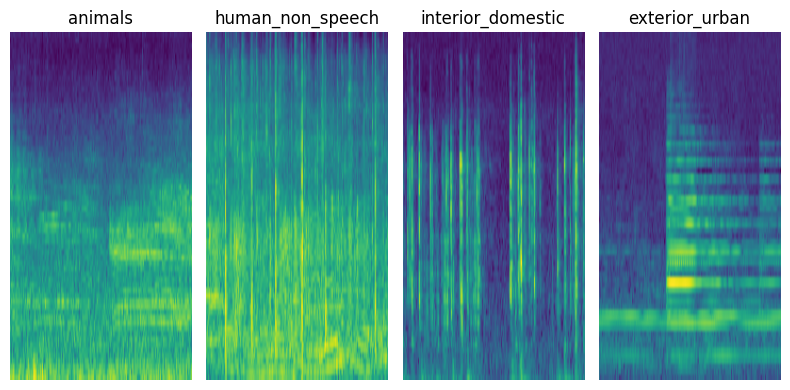

In [53]:
plt.figure(figsize=(8, 4))
for specs, batch_labels in train_ds.take(1):
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        plt.imshow(tf.squeeze(specs[i]).numpy().T, aspect='auto', origin='lower')
        plt.title(LABELS[int(batch_labels[i])])
        plt.axis('off')
plt.tight_layout()

## Regular TensorFlow Model

This is the laptop/Colab baseline. It is intentionally treated as the normal machine-learning version of the task.

The baseline should be reasonably strong before the TinyML comparison is interpreted. If the regular model is weak, then a quantized model will also be weak and the comparison mostly shows that the setup needs better features or more training.

The model below is still compact, but stronger than the first quick baseline. It uses log-mel inputs, several convolution blocks, batch normalization, and a little dropout. This is a reasonable middle ground: not huge, but not unfairly tiny either.

In [54]:
regular_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=INPUT_SHAPE),
    tf.keras.layers.Normalization(),

    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(96, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(96, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(LABELS), activation='softmax'),
])

# Adapt the normalization layer to the training features.
normalization_layer = regular_model.layers[0]
normalization_layer.adapt(train_ds.map(lambda x, y: x))

regular_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

regular_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 171, 64, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 171, 64, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 171, 64, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 85, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 85, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 85, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 42, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 42, 16, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 42, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 21, 8, 96)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 21, 8, 128)     │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 21, 8, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,080 (777.66 KB)

 Trainable params: 198,437 (775.14 KB)

 Non-trainable params: 643 (2.52 KB)

In [ ]:
history = regular_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-5),
    ],
)

Epoch 1/25
11/38 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.2371 - loss: 1.7945   

## Training Curves

The curves help distinguish two different problems:

- If training accuracy is low, the model/features are too weak.
- If training accuracy is high but validation accuracy is low, the model is overfitting.

This is useful for deciding whether to improve preprocessing, model size, or regularization.

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()

In [ ]:
regular_loss, regular_accuracy = regular_model.evaluate(test_ds)
print('Regular test accuracy:', regular_accuracy)

## Regular Model Diagnostics

Accuracy alone is not enough. A confusion matrix shows which categories the model confuses. This matters especially for ESC-50 because the 5 super-categories are broad and internally diverse. For example, `exterior_urban` contains sirens, engines, trains, fireworks, and hand saws.

Chance accuracy for 5 balanced labels is about 20%. If the regular model is only slightly above that, the baseline is weak and the TinyML comparison should not be overinterpreted. With the improved log-mel setup, the regular baseline should ideally be clearly above chance before we focus on quantization loss.

In [ ]:
regular_y_true = []
regular_y_pred = []

for specs, labels_batch in test_ds:
    probs = regular_model.predict(specs, verbose=0)
    preds = np.argmax(probs, axis=1)
    regular_y_true.extend(labels_batch.numpy().astype(int).tolist())
    regular_y_pred.extend(preds.astype(int).tolist())

regular_cm = confusion_matrix(regular_y_true, regular_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=regular_cm, display_labels=LABELS)
disp.plot(cmap='Greens', xticks_rotation=45)
plt.title('Regular TensorFlow confusion matrix')
plt.tight_layout()

### If The Regular Accuracy Is Low

Low accuracy is a useful result, but it changes the conclusion. It means the current baseline setup is too simple for the task, not that TinyML is impossible. Likely reasons:

- ESC-50 has only 2000 examples total. With 5 folds, the test fold is intentionally separate.
- The 5 super-categories are broad. One label can contain very different sound events.
- This notebook uses short cropped windows rather than full 5-second clips. The important sound may not always be in the center crop.
- The model is intentionally small and trained quickly so the comparison stays manageable.

If needed, improve the baseline before final reporting: use longer/random crops, log-mel features, more epochs, a slightly larger CNN, or pretrained audio embeddings. For the course comparison, the key is to compare regular vs quantized TinyML under the **same** preprocessing/task setup.

## Convert To TensorFlow Lite And Quantize

This section creates the TinyML-style comparison model. The model is converted to TensorFlow Lite and then quantized to int8.

Quantization matters because microcontrollers have much less memory and compute power than a laptop. Int8 values are smaller than float32 values, so the model file is usually much smaller. The tradeoff is that accuracy can get slightly worse. That tradeoff is one of the main things this notebook measures.

Strictly speaking, an ESP32 firmware would usually use **TFLite Micro**, not the normal Python TFLite interpreter. But the `.tflite` int8 model produced here is the relevant artifact direction for that later firmware step.

In [ ]:
MODELS_DIR = (TINYML_ROOT / 'models').resolve()
EXPORTED_DIR = (TINYML_ROOT / 'exported').resolve()
MODELS_DIR.mkdir(parents=True, exist_ok=True)
EXPORTED_DIR.mkdir(parents=True, exist_ok=True)

regular_keras_path = MODELS_DIR / 'regular_model.keras'
regular_tflite_path = MODELS_DIR / 'regular_model_float32.tflite'
tiny_tflite_path = MODELS_DIR / 'tiny_model_int8.tflite'

regular_model.save(regular_keras_path)

converter = tf.lite.TFLiteConverter.from_keras_model(regular_model)
regular_tflite = converter.convert()
regular_tflite_path.write_bytes(regular_tflite)

def representative_dataset():
    for specs, _ in train_ds.unbatch().batch(1).take(100):
        yield [tf.cast(specs, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(regular_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tiny_tflite = converter.convert()
tiny_tflite_path.write_bytes(tiny_tflite)

print('Saved:', regular_keras_path)
print('Saved:', regular_tflite_path)
print('Saved:', tiny_tflite_path)

In [ ]:
def evaluate_tflite_model(tflite_path, dataset):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    correct = 0
    total = 0
    y_true = []
    y_pred = []
    timings_ms = []

    for specs, labels_batch in dataset.unbatch().batch(1):
        input_data = specs.numpy().astype(np.float32)
        if input_details['dtype'] == np.int8:
            input_data = input_data / input_scale + input_zero_point
            input_data = np.clip(input_data, -128, 127).astype(np.int8)

        start = time.perf_counter()
        interpreter.set_tensor(input_details['index'], input_data)
        interpreter.invoke()
        elapsed_ms = (time.perf_counter() - start) * 1000

        output = interpreter.get_tensor(output_details['index'])[0]
        if output_details['dtype'] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output))
        true = int(labels_batch.numpy()[0])
        correct += int(pred == true)
        total += 1
        y_true.append(true)
        y_pred.append(pred)
        timings_ms.append(elapsed_ms)

    return {
        'accuracy': correct / total,
        'avg_inference_ms_laptop': float(np.mean(timings_ms)),
        'y_true': y_true,
        'y_pred': y_pred,
    }

regular_tflite_eval = evaluate_tflite_model(regular_tflite_path, test_ds)
tiny_tflite_eval = evaluate_tflite_model(tiny_tflite_path, test_ds)

regular_tflite_eval['accuracy'], tiny_tflite_eval['accuracy']

In [ ]:
size_regular_keras = regular_keras_path.stat().st_size
size_regular_tflite = regular_tflite_path.stat().st_size
size_tiny_tflite = tiny_tflite_path.stat().st_size

comparison = {
    'metric': ['target', 'numeric_format', 'model_size_bytes', 'accuracy', 'avg_inference_ms_laptop', 'openhab_payload'],
    'regular_tensorflow': [
        'Laptop baseline',
        'float32',
        size_regular_keras,
        float(regular_accuracy),
        'not measured here',
        'could send raw/central features, but not privacy-friendly',
    ],
    'tinyml_tflite_int8': [
        'ESP32 candidate style',
        'int8',
        size_tiny_tflite,
        tiny_tflite_eval['accuracy'],
        tiny_tflite_eval['avg_inference_ms_laptop'],
        'label/confidence/rms/inference_ms only',
    ],
}

for row in zip(comparison['metric'], comparison['regular_tensorflow'], comparison['tinyml_tflite_int8']):
    print(f'{row[0]:28s} | {str(row[1]):35s} | {row[2]}')

## TinyML Confusion Matrix

This is the same diagnostic view for the quantized TFLite model. Compare it with the regular confusion matrix above. The important question is not only whether TinyML is accurate, but **how much accuracy changes after conversion and quantization**.

In [ ]:
cm = confusion_matrix(tiny_tflite_eval['y_true'], tiny_tflite_eval['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('TinyML/TFLite int8 confusion matrix')
plt.tight_layout()

## Export Tiny Model As C Array

TFLite Micro examples often include the model as a C/C++ byte array. This export is not the full ESP32 firmware yet, but it creates the artifact shape that firmware would include later.

In [ ]:
def bytes_to_c_array(data, variable_name):
    hex_values = ', '.join(f'0x{byte:02x}' for byte in data)
    return (
        f'const unsigned char {variable_name}[] = {{{hex_values}}};\n'
        f'const unsigned int {variable_name}_len = {len(data)};\n'
    )

c_path = EXPORTED_DIR / 'tiny_model_int8.cc'
c_path.write_text(bytes_to_c_array(tiny_tflite_path.read_bytes(), 'tiny_model_int8'), encoding='utf-8')
print('Saved:', c_path)
print('C array size:', c_path.stat().st_size, 'bytes')

## Connection To The openHAB Safety System

In the existing openHAB project, the ESP8266/Tasmota nodes publish summarized sensor states such as motion, vibration, temperature, and touch acknowledgement. The future ESP32 audio node should follow the same idea: it should not stream raw audio into openHAB.

The deployed audio node should publish summarized inference data:

```json
{
  "label": "siren_alarm",
  "confidence": 0.87,
  "rms": 421,
  "inference_ms": 18,
  "model": "sound_v1_int8"
}
```

Planned MQTT topic:

```text
tele/safety_audio_1/CLASSIFICATION
```

Raw samples are still inspectable during development through the notebook, serial monitor, or temporary debug MQTT topics. They are not part of the normal openHAB data path.

## Interpretation Template

Use the results above to fill this in for the report/presentation:

- The regular TensorFlow model is easier to train and inspect on the laptop/Colab, but it is not the target deployment format for the ESP32.
- The quantized TFLite model is smaller and closer to TinyML deployment, but may lose some accuracy.
- Both models solve the same classification task and produce the same label set.
- The TinyML version changes the system architecture: inference moves to the edge node, and openHAB receives only summarized data.
- This supports the safety-monitoring concept because sound context can influence the risk score without streaming raw microphone data.

A good conclusion sentence could be:

```text
The TinyML model is not simply a smaller copy of the regular model; it changes where computation happens and what data leaves the sensor node.
```